**MALCOLM'S FINTECH PLAYGROUND**

pip install yfinance matplotlib pandas

In [1]:
import yfinance as yp                  #LOADS THE NECCESARY PACKAGES TO DO MY BIDDING #yp gives me market data 
import numpy as np                      #numpy my roided calculator 
import pandas as pd                      # the organiser and cleaner of my data/ MAID


**Download 6 months of historical stock data for Maybank (1155.KL) and MYEG (0138.KL) using yfinance. The data is filtered to include only 'Close' prices and 'Volume', and any missing values are removed using .dropna() to ensure clean time series for analysis.**

In [2]:
Maybank = yp.download("1155.KL",period="6mo")[['Close','Volume']].dropna() #py understands the stock as started on the exchange (1155.KL); also to eliminate empty slots use dropna(); [] call the variables undeer study 

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
MYEG= yp.download("0138.KL",period="6mo")[['Close','Volume']].dropna() #government technology firm

[*********************100%***********************]  1 of 1 completed


**OLD SCHOOL METHODS **
> Download the csv files from LSEG or NASDAQ or ZSE or KLSC or Bloomberg or Trading view [stock exchange platform]
> Then encode it using pandas ur data chef as follows
> Maybank=pd.read_excel('Maybank Data.xlsx',sheet_name='Maybank')
> MYEG=pd.read_excel('MYEG Data.xlsx',sheet_name='MYEG')

**ANALYSING MY DATA**

In [4]:
#DISPLAY THE HEAD 
print(Maybank.head())
print(MYEG.head())
print(Maybank.columns) # checks column names

Price          Close    Volume
Ticker       1155.KL   1155.KL
Date                          
2024-12-09  9.793940   9903600
2024-12-10  9.793940  14271600
2024-12-11  9.813334   8436000
2024-12-12  9.832727   8949000
2024-12-13  9.832727   7364400
Price        Close    Volume
Ticker     0138.KL   0138.KL
Date                        
2024-12-09   0.940  88181400
2024-12-10   0.935  29420500
2024-12-11   0.940  36971000
2024-12-12   0.945  38486100
2024-12-13   0.945  40047500
MultiIndex([( 'Close', '1155.KL'),
            ('Volume', '1155.KL')],
           names=['Price', 'Ticker'])


In [8]:
print(Maybank.columns)  #Multi-index form means 

MultiIndex([( 'Close', '1155.KL'),
            ('Volume', '1155.KL')],
           names=['Price', 'Ticker'])


In [9]:
print(MYEG.columns)   #Multi-index form means [Price represents both close and volume ; 'two columns merged into one column'

MultiIndex([( 'Close', '0138.KL'),
            ('Volume', '0138.KL')],
           names=['Price', 'Ticker'])


**DEALING WITH MULTI-INDEX FORM ISSUES** i.e missing data column [ date in this case]

STEPS
>if date column is missing we retrieve it by collapsing the multiindex form or creating list of dates

>Method 1 : Creating date values myself
Maybank["Date"] = pd.date_range(start="2024-01-01", periods=len(Maybank), freq="D")
Maybank.set_index("Date", inplace=True)

>Method 2 : Flatten the Multiindex Columns
Maybank.columns = ['_'.join(col) for col in Maybank.columns]
print(Maybank.head())


**TRAIL AND ERROR**



In [19]:
#Creating the dates 
Maybank["Date"] = pd.date_range(start="2024-11-20", periods=len(Maybank), freq="D") #set dates over valid time frame 
Maybank.set_index("Date", inplace=True)
print(Maybank.head())
print(Maybank.index) #check
#METHOD WAS SUCCESSFUL

Price          Close    Volume
Ticker       1155.KL   1155.KL
Date                          
2024-11-20  9.813334  24806300
2024-11-21  9.890909   8807300
2024-11-22  9.890909   8308300
2024-11-23  9.987879  27565700
2024-11-24  9.910303  12043400
DatetimeIndex(['2024-11-20', '2024-11-21', '2024-11-22', '2024-11-23',
               '2024-11-24', '2024-11-25', '2024-11-26', '2024-11-27',
               '2024-11-28', '2024-11-29',
               ...
               '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
               '2025-03-14', '2025-03-15', '2025-03-16', '2025-03-17',
               '2025-03-18', '2025-03-19'],
              dtype='datetime64[ns]', name='Date', length=120, freq=None)


In [5]:
#FLATTENING THE MULTIINDEX FORM 
Maybank.columns = ['_'.join(col) for col in Maybank.columns]
print(Maybank.head())
print(Maybank.index)

#METHOD WAS SUCCESSFUL

            Close_1155.KL  Volume_1155.KL
Date                                     
2024-12-09       9.793940         9903600
2024-12-10       9.793940        14271600
2024-12-11       9.813334         8436000
2024-12-12       9.832727         8949000
2024-12-13       9.832727         7364400
DatetimeIndex(['2024-12-09', '2024-12-10', '2024-12-11', '2024-12-12',
               '2024-12-13', '2024-12-16', '2024-12-17', '2024-12-18',
               '2024-12-19', '2024-12-20',
               ...
               '2025-05-26', '2025-05-27', '2025-05-28', '2025-05-29',
               '2025-05-30', '2025-06-03', '2025-06-04', '2025-06-05',
               '2025-06-06', '2025-06-09'],
              dtype='datetime64[ns]', name='Date', length=120, freq=None)


**CALCULATING DAILY PERCENTAGE RETURNS USING CLOSE PRICES AND period-over-period change in closing prices [pct_change()] method**

In [6]:
Maybank["Return"]=Maybank["Close_1155.KL"].pct_change() #on retriving columns ensure name is correct

In [7]:
print(Maybank["Return"])
#shows daily percentage changes in Maybank's stock price.
#Nan values ? means not a number===indicates missing or corrupt data in the data set

Date
2024-12-09         NaN
2024-12-10    0.000000
2024-12-11    0.001980
2024-12-12    0.001976
2024-12-13    0.000000
                ...   
2025-06-03   -0.002045
2025-06-04   -0.004098
2025-06-05   -0.002058
2025-06-06    0.000000
2025-06-09   -0.002062
Name: Return, Length: 120, dtype: float64


**CREATING A DATA FRAME**

import numpy as np
import pandas as pd

# Creating a DataFrame with NaN values
df = pd.DataFrame({'A': [1, 2, np.nan, 4], 'B': [np.nan, 2, 3, 4]})
print(df)
Columns A and B 


**MYEG ANALYSIS**

In [8]:
MYEG.columns = ['_'.join(col) for col in MYEG.columns]
print(MYEG.head())
print(MYEG.index)



            Close_0138.KL  Volume_0138.KL
Date                                     
2024-12-09          0.940        88181400
2024-12-10          0.935        29420500
2024-12-11          0.940        36971000
2024-12-12          0.945        38486100
2024-12-13          0.945        40047500
DatetimeIndex(['2024-12-09', '2024-12-10', '2024-12-11', '2024-12-12',
               '2024-12-13', '2024-12-16', '2024-12-17', '2024-12-18',
               '2024-12-19', '2024-12-20',
               ...
               '2025-05-26', '2025-05-27', '2025-05-28', '2025-05-29',
               '2025-05-30', '2025-06-03', '2025-06-04', '2025-06-05',
               '2025-06-06', '2025-06-09'],
              dtype='datetime64[ns]', name='Date', length=120, freq=None)


In [9]:
MYEG["Returns"]=MYEG["Close_0138.KL"].pct_change()#Daily % changes in prices 
print(MYEG["Returns"])

Date
2024-12-09         NaN
2024-12-10   -0.005319
2024-12-11    0.005348
2024-12-12    0.005319
2024-12-13    0.000000
                ...   
2025-06-03   -0.032609
2025-06-04    0.011236
2025-06-05    0.033333
2025-06-06    0.016129
2025-06-09    0.000000
Name: Returns, Length: 120, dtype: float64


**CLOSER LOOK BY GRAPHING**

In [10]:
import matplotlib.pyplot as mtp #Importing visuals package 

Axes(0.125,0.2;0.775x0.68)


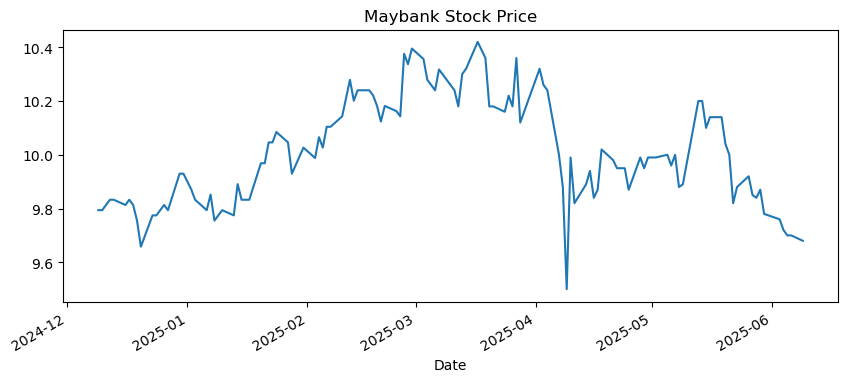

In [11]:
print(Maybank["Close_1155.KL"].plot(title="Maybank Stock Price",figsize=(10,4)))


Axes(0.125,0.11;0.775x0.77)


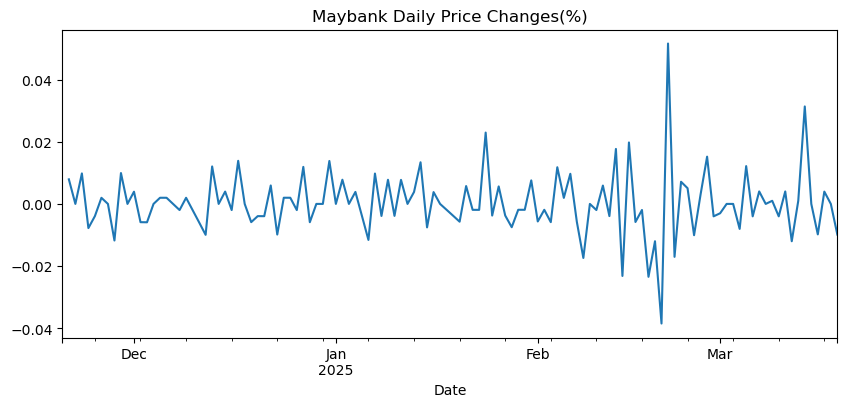

In [32]:
print(Maybank["Return"].plot(title="Maybank Daily Price Changes(%)", figsize=(10,4)))


Axes(0.125,0.2;0.775x0.68)


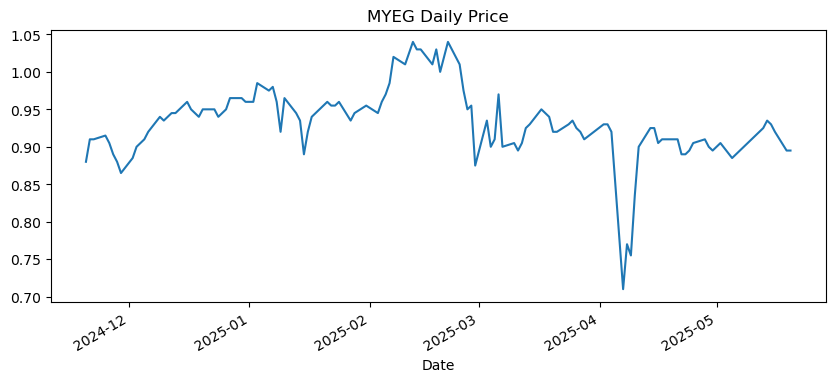

In [34]:
print(MYEG["Close_0138.KL"].plot(title="MYEG Daily Price", figsize=(10,4)))


Axes(0.125,0.2;0.775x0.68)


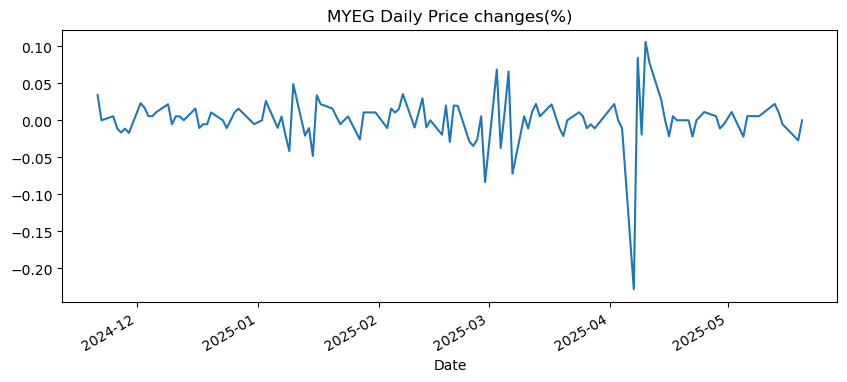

In [36]:
print(MYEG["Returns"].plot(title="MYEG Daily Price changes(%)", figsize=(10,4)))



**TECHNICAL ANALYSIS** 

In [12]:
!pip install pandas_ta

In [13]:
import pandas_ta as ta 


In [21]:
#KNOWN YOUR INDICATORS 
print(dir(ta))

['ALL_PATTERNS', 'AllStrategy', 'AnalysisIndicators', 'BasePandasObject', 'CANGLE_AGG', 'CDL_PATTERN_NAMES', 'Category', 'CommonStrategy', 'DataFrame', 'DistributionNotFound', 'EXCHANGE_TZ', 'Imports', 'List', 'Optional', 'PandasObject', 'Path', 'Pool', 'RATE', 'Series', 'Strategy', 'Timedelta', 'Timestamp', 'Tuple', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_dist', 'aberration', 'above', 'above_value', 'accbands', 'ad', 'adosc', 'adx', 'alma', 'alphavantage', 'amat', 'ao', 'aobv', 'apo', 'argmax', 'argmin', 'aroon', 'atr', 'av', 'bbands', 'below', 'below_value', 'bias', 'bop', 'brar', 'cagr', 'calmar_ratio', 'candle_color', 'candles', 'category_files', 'cci', 'cdl', 'cdl_doji', 'cdl_inside', 'cdl_pattern', 'cdl_z', 'cfo', 'cg', 'chop', 'cksp', 'cmf', 'cmo', 'combination', 'coppock', 'core', 'cpu_count', 'cross', 'cross_value', 'cti', 'cycles', 'data', 'dataclass', 'datetime', 'decay', 'decreasi

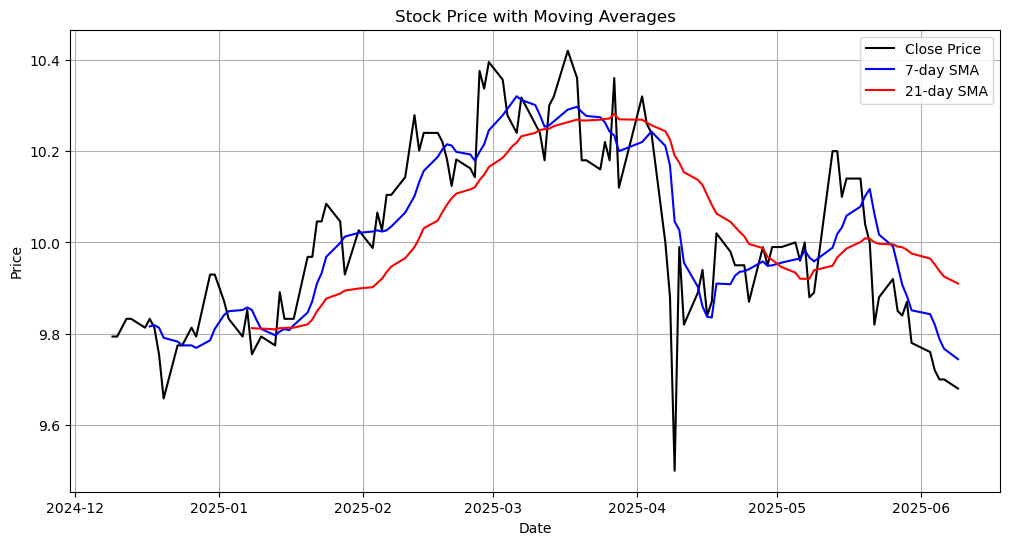

In [25]:


# Calculate indicators


Maybank['SMA_7'] =Maybank['Close_1155.KL'].rolling(7).mean()
Maybank['SMA_21'] =Maybank['Close_1155.KL'].rolling(21).mean()
Maybank['EMA_7'] = ta.ema(Maybank['Close_1155.KL'], window=7)
Maybank['EMA_21'] = ta.ema(Maybank['Close_1155.KL'], window=21)
Maybank['RSI'] = ta.rsi(Maybank['Close_1155.KL'], window=14)
Maybank['OBV'] = ta.obv(Maybank['Close_1155.KL'], Maybank['Volume_1155.KL'])

# Plot moving averages

mtp.figure(figsize=(12,6))
mtp.plot(Maybank.index, Maybank['Close_1155.KL'], label='Close Price', color='black')
mtp.plot(Maybank.index, Maybank['SMA_7'], label='7-day SMA', color='blue')
mtp.plot(Maybank.index, Maybank['SMA_21'], label='21-day SMA', color='red')
mtp.legend()
mtp.title('Stock Price with Moving Averages')
mtp.xlabel('Date')
mtp.ylabel('Price')
mtp.grid(True)
mtp.show()


**ADDING BOLLINGER BANDS** 

**SUMMARY STATISTICS**

In [37]:
print(Maybank["Return"].describe())
print(MYEG["Returns"].describe())

count    119.000000
mean       0.000243
std        0.010220
min       -0.038462
25%       -0.003996
50%        0.000000
75%        0.003992
max        0.051579
Name: Return, dtype: float64
count    119.000000
mean       0.000727
std        0.033270
min       -0.228261
25%       -0.010639
50%        0.000000
75%        0.011173
max        0.105960
Name: Returns, dtype: float64


**CONDITIONAL TRADES USING IF STATEMENTS** 

In [ ]:
#use news and events to understand the graphs 

**NEW PROJECT: MID CAP** 

In [19]:
import yfinance as yf
import pandas as pd 
import numpy as ny 

In [20]:
AIR_ASIA=yf.download("5099.KL",period="6mo")[["Close","Volume"]].dropna() #Flight and Travel agency 

[*********************100%***********************]  1 of 1 completed


In [21]:
print(AIR_ASIA.head())

Price        Close    Volume
Ticker     5099.KL   5099.KL
Date                        
2024-11-22    1.05   8272900
2024-11-25    1.05  12225200
2024-11-26    1.06  10193300
2024-11-27    1.07  16491200
2024-11-28    1.09  12996500


In [22]:
print(AIR_ASIA.index) #already in datetime index 

DatetimeIndex(['2024-11-22', '2024-11-25', '2024-11-26', '2024-11-27',
               '2024-11-28', '2024-11-29', '2024-12-02', '2024-12-03',
               '2024-12-04', '2024-12-05',
               ...
               '2025-05-08', '2025-05-09', '2025-05-13', '2025-05-14',
               '2025-05-15', '2025-05-16', '2025-05-19', '2025-05-20',
               '2025-05-21', '2025-05-22'],
              dtype='datetime64[ns]', name='Date', length=120, freq=None)


**SET TO DATE-TIME FORMAT FOR TIME-SERIES ANALYSIS**


In [23]:
AIR_ASIA.columns = ['_'.join(col) for col in AIR_ASIA.columns]
print(AIR_ASIA.head())
print(AIR_ASIA.index)



            Close_5099.KL  Volume_5099.KL
Date                                     
2024-11-22           1.05         8272900
2024-11-25           1.05        12225200
2024-11-26           1.06        10193300
2024-11-27           1.07        16491200
2024-11-28           1.09        12996500
DatetimeIndex(['2024-11-22', '2024-11-25', '2024-11-26', '2024-11-27',
               '2024-11-28', '2024-11-29', '2024-12-02', '2024-12-03',
               '2024-12-04', '2024-12-05',
               ...
               '2025-05-08', '2025-05-09', '2025-05-13', '2025-05-14',
               '2025-05-15', '2025-05-16', '2025-05-19', '2025-05-20',
               '2025-05-21', '2025-05-22'],
              dtype='datetime64[ns]', name='Date', length=120, freq=None)


In [25]:
AIR_ASIA["Returns"]=AIR_ASIA["Close_5099.KL"].pct_change()
print(AIR_ASIA["Returns"])               #Daily return based on percentage change in closing prices

Date
2024-11-22         NaN
2024-11-25    0.000000
2024-11-26    0.009524
2024-11-27    0.009434
2024-11-28    0.018692
                ...   
2025-05-16    0.010989
2025-05-19   -0.027174
2025-05-20   -0.016760
2025-05-21   -0.011364
2025-05-22   -0.028736
Name: Returns, Length: 120, dtype: float64


In [26]:
AIR_ASIA["Volatility"]=AIR_ASIA["Returns"].rolling(14).std()
print(AIR_ASIA["Volatility"])

Date
2024-11-22         NaN
2024-11-25         NaN
2024-11-26         NaN
2024-11-27         NaN
2024-11-28         NaN
                ...   
2025-05-16    0.023772
2025-05-19    0.025647
2025-05-20    0.026035
2025-05-21    0.026256
2025-05-22    0.027101
Name: Volatility, Length: 120, dtype: float64


**GRAPHING**

In [39]:
import matplotlib.pyplot as mt

In [37]:
AIR_ASIA["SMA_7"]=AIR_ASIA["Close_5099.KL"].rolling(window=7).mean()
AIR_ASIA["SMA_21"]=AIR_ASIA["Close_5099.KL"].rolling(window=21).mean()
print(AIR_ASIA["SMA_7"])
print (AIR_ASIA["SMA_21"])

Date
2024-11-22         NaN
2024-11-25         NaN
2024-11-26         NaN
2024-11-27         NaN
2024-11-28         NaN
                ...   
2025-05-16    0.908571
2025-05-19    0.910714
2025-05-20    0.906429
2025-05-21    0.900714
2025-05-22    0.891429
Name: SMA_7, Length: 120, dtype: float64
Date
2024-11-22         NaN
2024-11-25         NaN
2024-11-26         NaN
2024-11-27         NaN
2024-11-28         NaN
                ...   
2025-05-16    0.835000
2025-05-19    0.841667
2025-05-20    0.847143
2025-05-21    0.851667
2025-05-22    0.855714
Name: SMA_21, Length: 120, dtype: float64


In [ ]:
AIR_ASIA["SMA_7"].plot(title="7 Day Moving Average",

**DISTRIBUTION OF RETURNS**